In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from category_encoders.count import CountEncoder
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,average_precision_score,
    confusion_matrix, matthews_corrcoef,balanced_accuracy_score,cohen_kappa_score
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import (
    SVMSMOTE, BorderlineSMOTE,
    ADASYN, KMeansSMOTE, SMOTE
)
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import TomekLinks
from sklearn.svm import SVC
import os
from matplotlib.widgets import Lasso
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegressionCV, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.base import clone

import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from imblearn.under_sampling import EditedNearestNeighbours


c:\Users\duyp6\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df_train = pd.read_csv("data/processed/processed_train_data.csv")

df_test = pd.read_csv("data/processed/processed_test_data.csv")

# df_train = pd.read_csv("data/raw/raw_not_null_train.csv")

# df_test = pd.read_csv("data/raw/raw_not_null_test.csv")

In [3]:
df_train.columns

Index(['SEQN', 'Gender', 'Age', 'Race', 'PIR', 'Weight', 'Height', 'BMI',
       'WaistCircumference', 'Hba1c', 'FastingGlucose', 'Albumin', 'ALT',
       'AST', 'AlkalinePhosphotase', 'BUN', 'GGT', 'TotalBilirubin',
       'UricAcid', 'Creatinine', 'TotalCholesterol', 'HDLCholesterol',
       'Triglycerides', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'milk_consumption', 'YearStart',
       'label'],
      dtype='object')

In [4]:
columns_remove = ['SEQN', 'YearStart']

# columns_remove.append('VitaminD')

In [5]:
df_train.drop(columns=columns_remove, inplace=True)
df_test.drop(columns=columns_remove, inplace=True)

In [6]:
df_train = df_train[df_train['milk_consumption']<=5]
df_test = df_test[df_test['milk_consumption']<=5]

In [7]:
print(df_train['label'].value_counts())
print(df_test['label'].value_counts())

label
0.0    11831
1.0     6412
Name: count, dtype: int64
label
0.0    3091
1.0    1359
Name: count, dtype: int64


## FEATURE SELECTION

### Feature Correlation

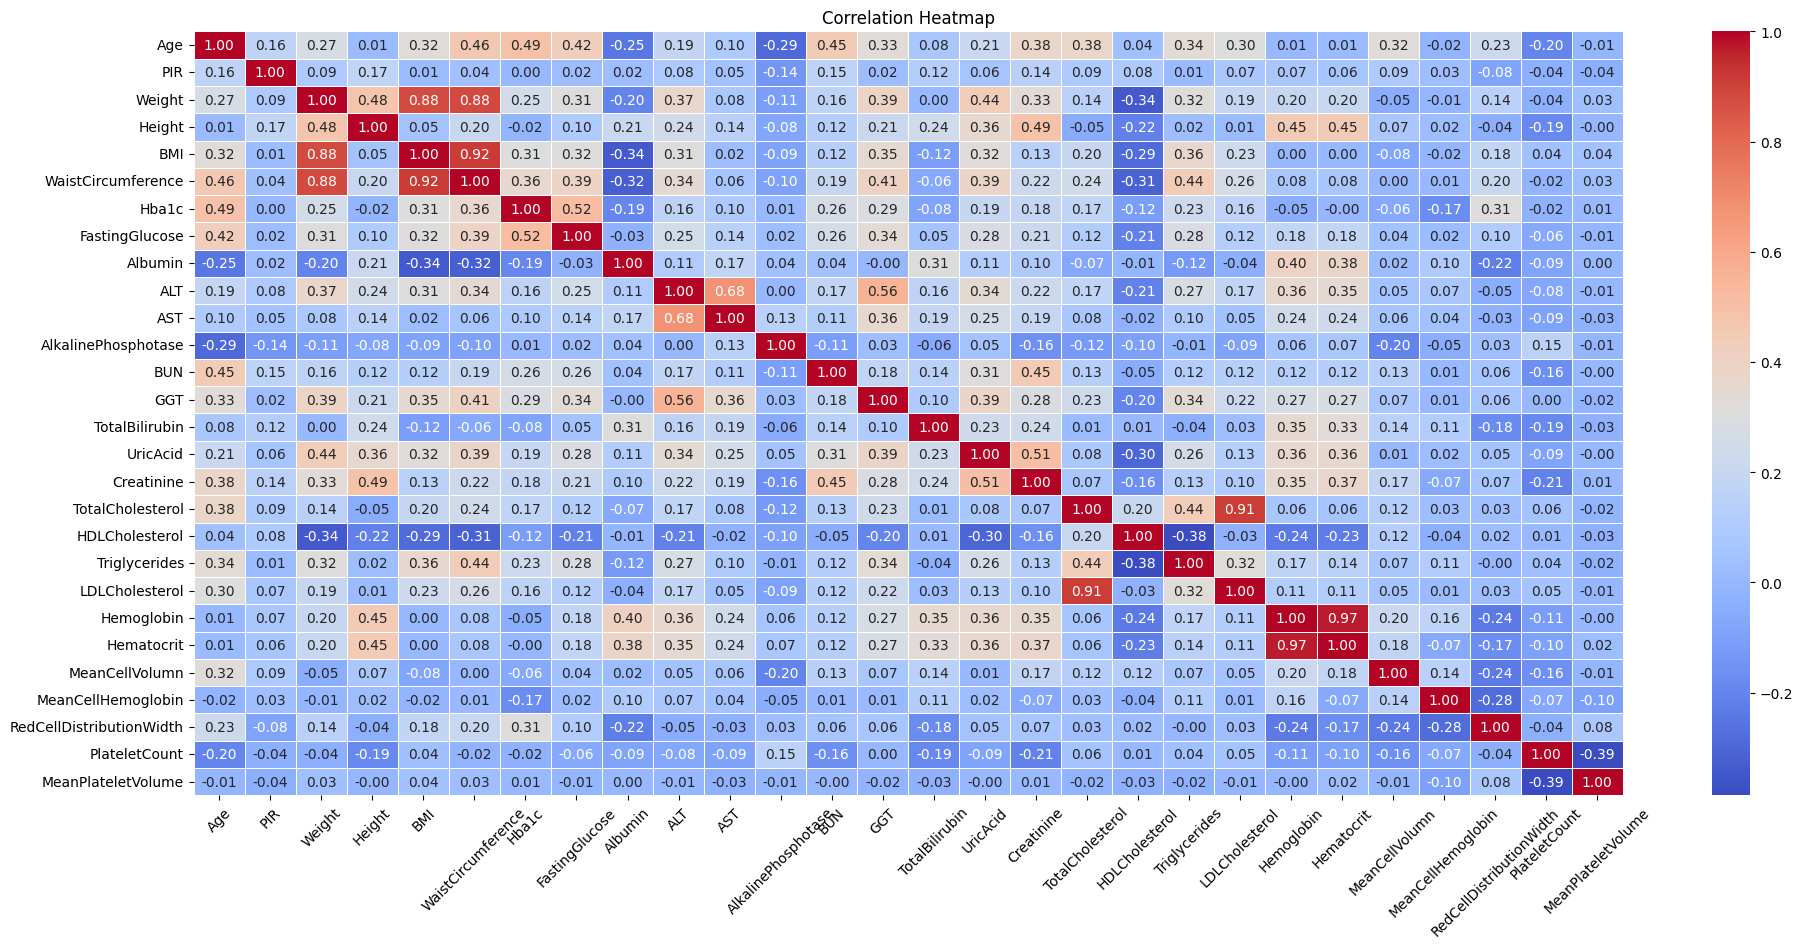

In [8]:
# Draw heat map to visualize correlation
df_corr = df_train.copy()
df_corr.drop(columns=[
    "Gender", "milk_consumption",
    "Race", "label"
], inplace=True)

# Check consistency between columns with spearman correlation
correlation_matrix = df_corr.corr(method = "spearman")

plt.figure(figsize=(20, 10))  # Kích thước biểu đồ
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

### Feature Importances

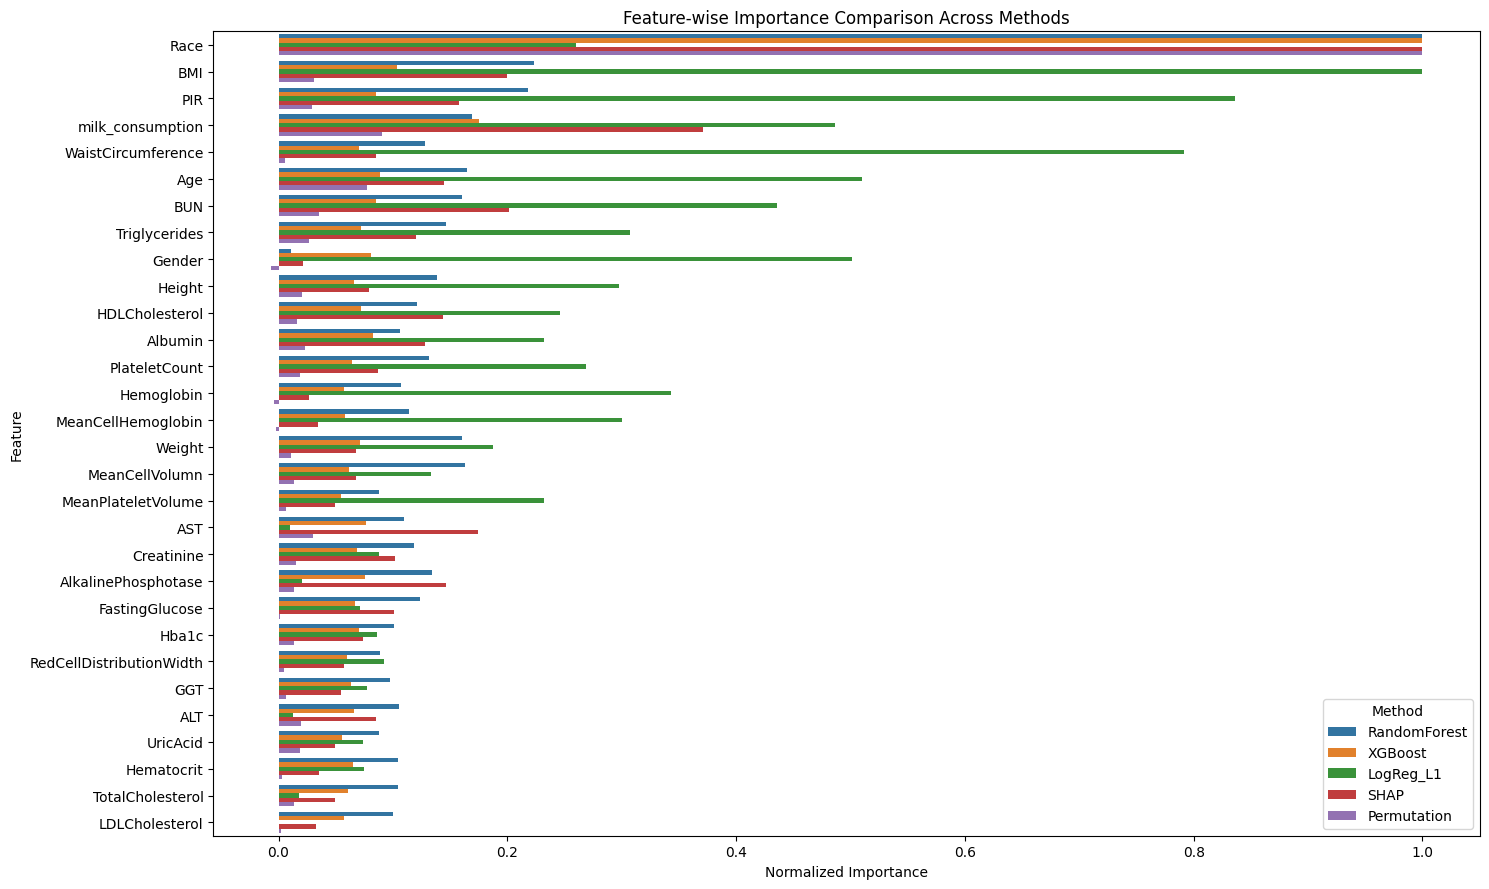

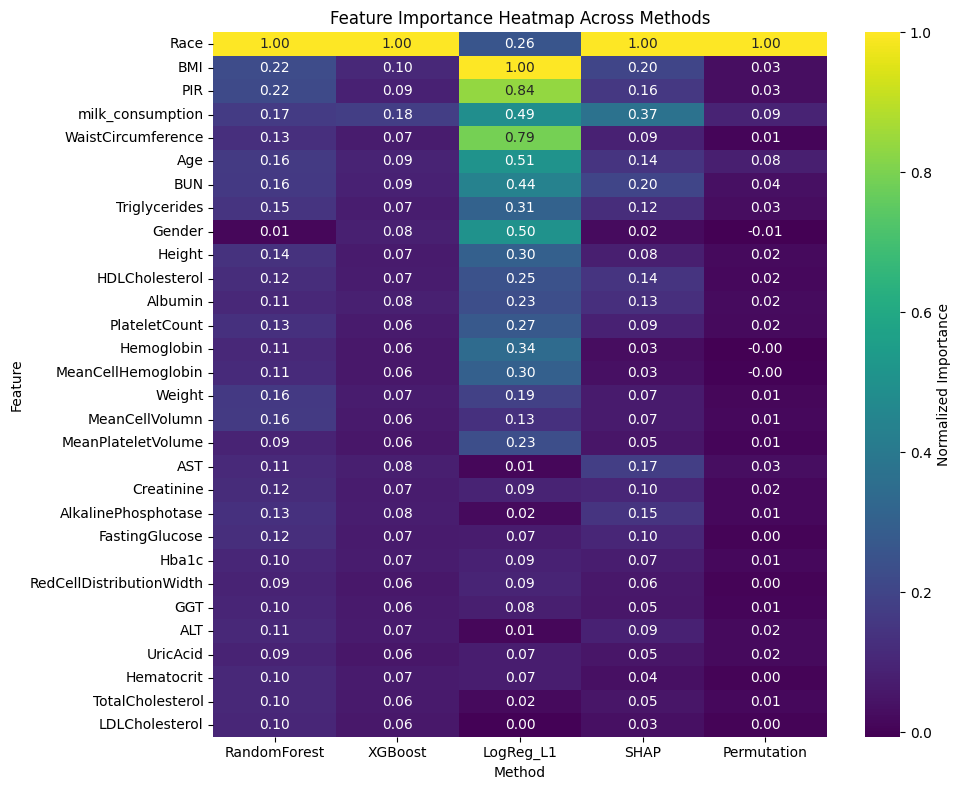

C:\Users\duyp6\AppData\Local\Temp\ipykernel_24072\4254759544.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="MethodSupport", data=plot_df, palette="Blues_r")


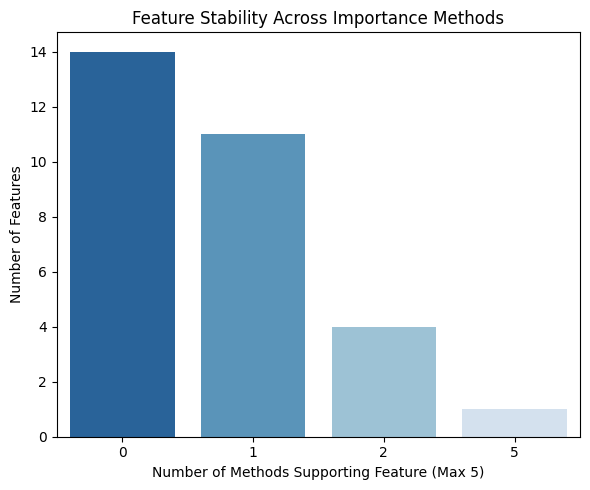

--- KẾT QUẢ RÚT TRÍCH ĐẶC TRƯNG ---
1. Tổng số cột ban đầu: 31 cột
2. Số cột chọn theo Đồng thuận (Support >= 2): 5 cột
3. Số cột chọn theo Top 15 MeanScore: 15 cột

=> DANH SÁCH CỘT THEO SỰ ĐỒNG THUẬN (NÊN DÙNG):
['Race', 'BMI', 'PIR', 'milk_consumption', 'BUN']

=> DANH SÁCH CỘT THEO TOP MEAN SCORE (THAM KHẢO):
['Race', 'BMI', 'PIR', 'milk_consumption', 'WaistCircumference', 'Age', 'BUN', 'Triglycerides', 'Gender', 'Height', 'HDLCholesterol', 'Albumin', 'PlateletCount', 'Hemoglobin', 'MeanCellHemoglobin']


In [11]:
X = df_train.drop(columns=['label'])  
y = df_train['label']

categorical_columns = ["Gender", "milk_consumption", "Race"]
numeric_columns = [col for col in X.columns if col not in categorical_columns]
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

robust_scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = robust_scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = robust_scaler.transform(X_test[numeric_columns])


rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_importance = rf.feature_importances_

xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=6, 
    subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', 
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
xgb_importance = xgb_model.feature_importances_

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_scaled)
shap_importance = np.abs(shap_values).mean(axis=0)

logreg_l1 = LogisticRegressionCV(
    Cs=10, cv=5, penalty='l1', solver='saga', scoring='f1', 
    class_weight='balanced', max_iter=5000, random_state=42
)
logreg_l1.fit(X_train_scaled, y_train)
logreg_importance = np.abs(logreg_l1.coef_).ravel()

def cv_permutation(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    imps = []
    X_reset = X.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)
    
    for tr, val in skf.split(X_reset, y_reset):
        m = clone(model)
        m.fit(X_reset.iloc[tr], y_reset.iloc[tr])
        r = permutation_importance(
            m, X_reset.iloc[val], y_reset.iloc[val],
            n_repeats=10, random_state=42
        )
        imps.append(r.importances_mean) 
    return np.mean(imps, axis=0)

perm_importance = cv_permutation(xgb_model, X_train_scaled, y_train)


importance_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "RandomForest": rf_importance,
    "XGBoost": xgb_importance,
    "LogReg_L1": logreg_importance,
    "SHAP": shap_importance,
    "Permutation": perm_importance
})

methods = ["RandomForest", "XGBoost", "LogReg_L1", "SHAP", "Permutation"]

for col in methods:
    importance_df[col] = importance_df[col] / (importance_df[col].max() + 1e-9)

importance_df["MeanScore"] = importance_df[methods].mean(axis=1)

top_k = 30
plot_df = importance_df.sort_values("MeanScore", ascending=False).head(top_k).set_index("Feature")


plot_df_long = plot_df[methods].reset_index().melt(
    id_vars="Feature", value_vars=methods, var_name="Method", value_name="Importance"
)
plt.figure(figsize=(15, 9))
sns.barplot(data=plot_df_long, y="Feature", x="Importance", hue="Method")
plt.title("Feature-wise Importance Comparison Across Methods")
plt.xlabel("Normalized Importance")
plt.ylabel("Feature")
plt.legend(title="Method", loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(plot_df[methods], annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": "Normalized Importance"})
plt.title("Feature Importance Heatmap Across Methods")
plt.xlabel("Method")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plot_df["MethodSupport"] = sum((plot_df[method] > 0.2).astype(int) for method in methods)

plt.figure(figsize=(6, 5))
sns.countplot(x="MethodSupport", data=plot_df, palette="Blues_r")
plt.xlabel(f"Number of Methods Supporting Feature (Max {len(methods)})")
plt.ylabel("Number of Features")
plt.title("Feature Stability Across Importance Methods")
plt.tight_layout()
plt.show()

MIN_SUPPORT = 2
selected_features_support = plot_df[plot_df["MethodSupport"] >= MIN_SUPPORT].index.tolist()

TOP_N = 15 
selected_features_mean = plot_df.sort_values("MeanScore", ascending=False).head(TOP_N).index.tolist()

print("--- KẾT QUẢ RÚT TRÍCH ĐẶC TRƯNG ---")
print(f"1. Tổng số cột ban đầu: {len(X_train_scaled.columns)} cột")
print(f"2. Số cột chọn theo Đồng thuận (Support >= {MIN_SUPPORT}): {len(selected_features_support)} cột")
print(f"3. Số cột chọn theo Top {TOP_N} MeanScore: {len(selected_features_mean)} cột")

print("\n=> DANH SÁCH CỘT THEO SỰ ĐỒNG THUẬN (NÊN DÙNG):")
print(selected_features_support)
print("\n=> DANH SÁCH CỘT THEO TOP MEAN SCORE (THAM KHẢO):")
print(selected_features_mean)


# Traning model

### Before traning

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18243 entries, 0 to 18242
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    18243 non-null  float64
 1   Age                       18243 non-null  float64
 2   Race                      18243 non-null  float64
 3   PIR                       18243 non-null  float64
 4   Weight                    18243 non-null  float64
 5   Height                    18243 non-null  float64
 6   BMI                       18243 non-null  float64
 7   WaistCircumference        18243 non-null  float64
 8   Hba1c                     18243 non-null  float64
 9   FastingGlucose            18243 non-null  float64
 10  Albumin                   18243 non-null  float64
 11  ALT                       18243 non-null  float64
 12  AST                       18243 non-null  float64
 13  AlkalinePhosphotase       18243 non-null  float64
 14  BUN   

In [13]:
category_columns = [
    'Gender','Race', 'milk_consumption', 'label'
]

unuseful_columns = [
    "ALT", "Weight", "Height",
    "FastingGlucose", "UricAcid", 
    "MeanPlateletVolume", "TotalCholesterol",
    "MeanCellVolumn", "MeanCellHemoglobin", 
    "RedCellDistributionWidth", "Creatinine"
]

In [14]:
df_train.drop(columns=unuseful_columns,inplace=True)
df_test = df_test[df_train.columns]

In [15]:
print(len(df_train.columns))
df_train.columns

21


Index(['Gender', 'Age', 'Race', 'PIR', 'BMI', 'WaistCircumference', 'Hba1c',
       'Albumin', 'AST', 'AlkalinePhosphotase', 'BUN', 'GGT', 'TotalBilirubin',
       'HDLCholesterol', 'Triglycerides', 'LDLCholesterol', 'Hemoglobin',
       'Hematocrit', 'PlateletCount', 'milk_consumption', 'label'],
      dtype='object')

### Prepare Model

In [ ]:

# ====== 1) Base learners ======
# base_learners = [
#     ('lightgbm', LGBMClassifier(n_estimators=100, max_depth=6, num_leaves=31, learning_rate=0.05, random_state=42, verbose=-1)),
#     ('xgboost', XGBClassifier(n_estimators=80, learning_rate=0.066, random_state=42, verbosity=0)),
#     ('RandomForest', rf_setups['Regularized']), 
#     ('catboost', CatBoostClassifier(
#         depth=6,
#         learning_rate=0.02,
#         iterations=1000,
#         loss_function='Logloss',
#         verbose=False,
#         random_state=42
#     )),
# ]
# base_learners = [
#     ('lightgbm', lgbm_setups['Regularized']),
#     ('xgboost', xgb_setups['Balanced']),
#     ('catboost', cb_setups['Regularized']),
    
#     ('randomforest', rf_setups['RobustSubsample']),
    
#     # ('svm_rbf', svm_setups['Balanced']),
#     # ('mlp_nn', mlp_setups['Biomedical_Net'])
# ]

# ====== 2) Meta-learner ======
# meta_learner = LogisticRegression(
#     max_iter=3000,
#     solver='saga',   
#     C=0.2,
#     random_state=42
# )
# meta_learner = lr_setups['L2_Standard']

# # ====== 3) Stacking classifier ======
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# stacking_clf = StackingClassifier(
#     estimators=base_learners,
#     final_estimator=meta_learner,
#     stack_method="predict_proba",  
#     cv=skf,
#     n_jobs=1
# )

In [12]:
# Set up parametrs for algorithms
dt_setups = {
    "Shallow": DecisionTreeClassifier(criterion="gini", max_depth=5, min_samples_split=10, min_samples_leaf=4, random_state=42),
    "Balanced": DecisionTreeClassifier(criterion="entropy", max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42),
    "Deep": DecisionTreeClassifier(criterion="gini", max_depth=20, min_samples_split=2, min_samples_leaf=1, random_state=42),
    "Randomized": DecisionTreeClassifier(criterion="log_loss", splitter="random", max_depth=None, min_samples_split=20, min_samples_leaf=6, random_state=42),
    "WideFeatures": DecisionTreeClassifier(criterion="entropy", splitter="best", max_depth=30, min_samples_split=5, min_samples_leaf=2, max_features="sqrt", random_state=42)
}

gbc_setups = {
    "Balanced": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "ShallowFast": GradientBoostingClassifier(n_estimators=80, learning_rate=0.2, max_depth=2, subsample=0.8, random_state=42),
    "Regularized": GradientBoostingClassifier(n_estimators=200, learning_rate=0.01, max_depth=4, min_samples_split=20, min_samples_leaf=5, random_state=42),
    "Deep": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.9, random_state=42),
    "RobustSubsample": GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=5, subsample=0.7, max_features="sqrt", random_state=42),
    "Conservative": GradientBoostingClassifier(n_estimators=500, learning_rate=0.01, max_depth=3, subsample=0.8, max_features="log2", random_state=42)
}

rf_setups = {
    "Balanced": RandomForestClassifier(
        n_estimators=100, max_depth=None, random_state=42
    ),
    "ShallowFast": RandomForestClassifier(
        n_estimators=50, max_depth=5, max_features="sqrt", random_state=42
    ),
    "Deep": RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_split=5,
        min_samples_leaf=2, random_state=42
    ),
    "Regularized": RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=10,
        min_samples_leaf=4, max_features=0.6, random_state=42
    ),
    "Conservative": RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_split=20,
        min_samples_leaf=10, max_features="log2", random_state=42
    ),
    "RobustSubsample": RandomForestClassifier(
        n_estimators=150, max_depth=15, min_samples_split=5,
        min_samples_leaf=3, bootstrap=True, max_features="sqrt",
        random_state=42
    ),
    "Lightweight": RandomForestClassifier(
        n_estimators=50, max_depth=8, max_features=0.5, random_state=42
    ),
    "Heavy": RandomForestClassifier(
        n_estimators=1000, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, max_features=None, random_state=42, n_jobs=-1
    ),
}

lgbm_setups = {
    "ShallowFast": LGBMClassifier(n_estimators=80, max_depth=4, num_leaves=15, learning_rate=0.05, random_state=42, verbose=-1),
    "Balanced": LGBMClassifier(n_estimators=120, max_depth=6, num_leaves=31, learning_rate=0.05, random_state=42, verbose=-1),
    "Regularized": LGBMClassifier(
        n_estimators=150, max_depth=5, num_leaves=20, 
        min_child_samples=40, 
        learning_rate=0.03, random_state=42, verbose=-1
    ),
    "Deep": LGBMClassifier(n_estimators=200, max_depth=8, num_leaves=63, learning_rate=0.05, random_state=42, verbose=-1)
}

xgb_setups = {
    "ShallowFast": XGBClassifier(n_estimators=80, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0),
    "Balanced": XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.066, random_state=42, verbosity=0),
    "Regularized": XGBClassifier(
        n_estimators=120, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, 
        gamma=1.0, random_state=42, verbosity=0
    ),
    "Deep": XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.05, random_state=42, verbosity=0)
}

cb_setups = {
    "Fast": CatBoostClassifier(iterations=300, depth=4, learning_rate=0.05, loss_function='Logloss', verbose=False, random_state=42),
    "Balanced": CatBoostClassifier(iterations=800, depth=6, learning_rate=0.02, loss_function='Logloss', verbose=False, random_state=42),
    "Regularized": CatBoostClassifier(
        iterations=1000, depth=5, learning_rate=0.01, 
        l2_leaf_reg=5.0, 
        loss_function='Logloss', verbose=False, random_state=42
    )
}


svm_setups = {
    "Linear_Approx": SVC(kernel='linear', C=0.5, probability=True, random_state=42), 
    "Balanced": SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42), #
    "Strict": SVC(kernel='rbf', C=10.0, gamma=0.01, probability=True, random_state=42)
}


lr_setups = {
    "L2_Standard": LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, max_iter=3000, random_state=42),
    "ElasticNet": LogisticRegression(
        penalty='elasticnet', solver='saga', l1_ratio=0.5, 
        C=0.5, max_iter=2000, random_state=42
    ),
    "Strong_Penalty": LogisticRegression(penalty='l2', solver='lbfgs', C=0.1, max_iter=1000, random_state=42) 
}

mlp_setups = {
    "Biomedical_Net": MLPClassifier(
        hidden_layer_sizes=(64, 32), 
        activation='relu',           
        solver='adam',              
        alpha=0.01,                 
        batch_size=256,            
        early_stopping=False,       
        max_iter=500,                
        random_state=42
    )
}

In [10]:
classifiers = {
    'LightGBM': LGBMClassifier(
        n_estimators=120, max_depth=6, num_leaves=31, 
        learning_rate=0.05, random_state=42, verbose=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=80, learning_rate=0.066, 
        random_state=42, verbosity=0
    ),

    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=80, learning_rate=0.05, random_state=42
    ),

    'RandomForest': RandomForestClassifier(
        n_estimators=100, random_state=42
    ),

    'Naive Bayes': GaussianNB(var_smoothing=1e-10),

    'LogisticRegression': LogisticRegression(
        solver='lbfgs', max_iter=500, random_state=42
    ),
    
    'ElasticNetLR': LogisticRegression(
        penalty='elasticnet', solver='saga', l1_ratio=0.5, 
        C=1.0, max_iter=1000, random_state=42
    ),

    'SVM': SVC(kernel='rbf', C=10, gamma=0.01, probability=True, random_state=42),
}


In [ ]:
# Train/test split
X_test = df_test.drop(columns=['label'])
y_test = df_test['label']

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    df_train.drop(columns='label'), 
    df_train['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_train['label'] 
)


print("\n--- Start to Balance Data ---")

idx_majority = y_train_sub[y_train_sub == 0].index
idx_minority = y_train_sub[y_train_sub == 1].index


keep_ratio = 0.5
keep_count = int(len(idx_minority) * keep_ratio)


np.random.seed(42)
idx_minority_reduced = np.random.choice(idx_minority, size=keep_count, replace=False)

final_indices = np.concatenate([idx_majority, idx_minority_reduced])

X_train_sub = X_train_sub.loc[final_indices]
y_train_sub = y_train_sub.loc[final_indices]

X_train_sub = X_train_sub.sample(frac=1, random_state=42)
y_train_sub = y_train_sub.loc[X_train_sub.index]

print(f"Number of majority class samples (Label 0): {len(idx_majority)}")
print(f"Number of minority class samples (Label 1) initially: {len(idx_minority)}")
print(f"Number of minority class samples (Label 1) after reduction: {len(idx_minority_reduced)}")
print(f"Current minority class ratio: {(len(idx_minority_reduced) / len(final_indices) * 100):.2f}%")
print("----------------------------------------\n")

In [ ]:
# Define numeric and categorical columns
categorical_cols = category_columns
categorical_encode_cols = ["Race"]
numeric_cols = [col for col in df_train.columns if col not in categorical_cols]


# Preprocessor
cat_encoders = {
    "cat_none": "passthrough",
    "cat_ohe": OneHotEncoder(handle_unknown="ignore", sparse_output=False),
    "cat_count": CountEncoder(cols=categorical_encode_cols)
}

num_scalers = {
    "num_noscale": "passthrough",
    "num_robust": RobustScaler(),
    "num_standard": StandardScaler()
}

def build_preprocessor(cat_encoder, num_scaler):
    return ColumnTransformer(
        transformers=[
            ("cat", cat_encoder, categorical_encode_cols),
            ("num", num_scaler, numeric_cols)
        ],
        remainder="passthrough"
)


In [ ]:
# SMOTE setup 
smote_options = {
    "nosmote": [], 

    "smote": [
        ("smote", SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.6))
    ],

    "svm_smote": [
        ("svm_smote", SVMSMOTE(
            sampling_strategy=0.6,  
            random_state=42,
            k_neighbors=5,           
            m_neighbors=10,         
            svm_estimator=SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
        ))
    ],

    # "smote_enn": [
    #     ("smote", SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.6)),
    #     ("enn", EditedNearestNeighbours(sampling_strategy='auto', n_neighbors=3))
    # ],

    # "svm_smote_enn": [
    #     ("svm_smote", SVMSMOTE(
    #         random_state=42, 
    #         sampling_strategy=0.6, 
    #         k_neighbors=10, 
    #         m_neighbors=15, 
    #         svm_estimator=SVC(kernel="linear", C=1.0, random_state=42)
    #     )),
    #     ("enn", EditedNearestNeighbours(sampling_strategy='all', n_neighbors=3))
    # ],
    
    # "smote_tomek": [
    #     ("smote", SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.6)),
    #     ("tomek", TomekLinks(sampling_strategy='all'))
    # ],

    # "svm_smote_tomek": [
    #     ("svm_smote", SVMSMOTE(
    #         random_state=42, 
    #         sampling_strategy=0.6, 
    #         k_neighbors=10, 
    #         m_neighbors=15, 
    #         svm_estimator=SVC(kernel="linear", C=1.0, random_state=42)
    #     )),
    #     ("tomek", TomekLinks(sampling_strategy='all'))
    # ],

    "borderline_smote": [
        ("borderline_smote", BorderlineSMOTE(random_state=42, kind="borderline-1", k_neighbors=10, sampling_strategy=0.6))
    ],

    "adasyn": [
        ("adasyn", ADASYN(random_state=42, n_neighbors=10, sampling_strategy=0.6))
    ],

    "kmeans_smote": [
        ("kmeans_smote", KMeansSMOTE(random_state=42, k_neighbors=10, cluster_balance_threshold=0.1, sampling_strategy=0.6))
    ]
}

In [19]:
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
def get_stacking_clf(smote_step_list):
    base_models = [
        ('lightgbm', LGBMClassifier(n_estimators=100, max_depth=6, num_leaves=31, learning_rate=0.05, random_state=42, verbose=-1)),
        ('catboost', CatBoostClassifier(
            depth=6,
            learning_rate=0.02,
            iterations=1000,
            loss_function='Logloss',
            verbose=False,
            random_state=42
        )),        
        ('randomforest', RandomForestClassifier(n_estimators=150, max_depth=15, min_samples_split=5, min_samples_leaf=2, max_features="sqrt", random_state=42)),

        # ('svm_rbf', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)),
                
        ('logistic', LogisticRegression(penalty='l2', solver='lbfgs', C=1.0, max_iter=3000, random_state=42))
        # ('linear_svm', SGDClassifier(loss='modified_huber', penalty='l2', alpha=0.001, max_iter=1000, random_state=42)),
        # ('naive_bayes', GaussianNB()),
        # ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance'))
        # ('mlp_shallow', MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='adam', max_iter=500, early_stopping=True, random_state=42))
    ]
    
    base_learners = []
    for name, model in base_models:
            if not smote_step_list: 
                base_learners.append((name, clone(model)))
            else:
                steps = []
                for step_name, step_obj in smote_step_list:
                    steps.append((step_name, clone(step_obj)))
                
                steps.append(('model', clone(model)))
                
                base_learners.append((name, ImbPipeline(steps)))
            
    meta_learner = LogisticRegression(
            penalty='l2', 
            solver='lbfgs', 
            C=0.1,  
            max_iter=3000, 
            class_weight='balanced',
            random_state=42,
    )

    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    stacking_clf = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        stack_method="predict_proba",  
        # cv=skf
    )
    return stacking_clf

### Traning model

In [20]:
#  Build pipelines for all experiments
pipelines = {}
for cat_name, cat_enc in cat_encoders.items():
    for num_name, num_scaler in num_scalers.items():
        for smote_name, smote_step_list in smote_options.items():

            preprocessor = build_preprocessor(cat_enc, num_scaler)
            
            # 2.1 Pipeline for Single Models
            for model_name, clf in classifiers.items():
                steps = [("preprocess", preprocessor)]
                
                if smote_step_list: 
                    for step_name, step_obj in smote_step_list:
                        steps.append((step_name, clone(step_obj)))
                        
                steps.append(("classifier", clone(clf)))
                
                pipe_name = f"{model_name}__{cat_name}__{num_name}__{smote_name}"
                pipelines[pipe_name] = {
                    "model_name": model_name,
                    "smote_name": smote_name,
                    "pipeline": ImbPipeline(steps) 
                }
                
            # 2.2 Stacking Model
            stack_clf = get_stacking_clf(smote_step_list)
            pipe_name = f"Stacking__{cat_name}__{num_name}__{smote_name}"
            pipelines[pipe_name] = {
                "model_name": "Stacking",
                "smote_name": smote_name,
                "pipeline": Pipeline([
                    ("preprocess", preprocessor),
                    ("classifier", stack_clf)
                ])
            }

In [ ]:
rows_detailed = []
rows_summary = []
rows_proba = [] 

data_versions = [
    "Full data_processed",
]

def find_best_threshold(y_true, y_proba, metric="f1_macro"):

    thresholds = np.linspace(0.01, 0.99, 1000) 
    best_thr = 0.5
    best_score = -1.0

    y_true = np.array(y_true)

    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)

        if metric == "f1":
            score = f1_score(y_true, y_pred_thr, average="binary", zero_division=0)
        elif metric == "f1_macro":
            score = f1_score(y_true, y_pred_thr, average="macro", zero_division=0)
        elif metric == "balanced_acc":
            score = balanced_accuracy_score(y_true, y_pred_thr)
        else:
            raise ValueError(f"Metric '{metric}' not supported for threshold tuning.")

        if score > best_score:
            best_score = score
            best_thr = thr
            
    return round(best_thr, 4), round(best_score, 4)


# Folder to store results
ROOT_DIR = r"notebooks/experiment_results"
FOLDERNAME = "clean_experiment"
STORE_PATH = os.path.join(ROOT_DIR, FOLDERNAME)

os.makedirs(STORE_PATH, exist_ok=True)

print("RESULT WILL BE STORED IN:", STORE_PATH)
for version in data_versions:
    for pipe_name, exp_dict in pipelines.items():
        model_name = exp_dict["model_name"]
        smote_name = exp_dict["smote_name"]
        master_pipe = exp_dict["pipeline"]

        summary_row = {
            "Data versioning": f"{version} - {pipe_name}",
        }

        try:
            # Training
            start = time.time()
            master_pipe.fit(X_train_sub, y_train_sub)
            train_time = time.time() - start

            # Threadhold tuning on validation set
            y_val_proba1 = master_pipe.predict_proba(X_val)[:, 1]
            best_thr, _ = find_best_threshold(
                y_val, 
                y_val_proba1, 
                metric="f1_macro" 
            )

            # Testing
            start_test = time.time()
            y_test_proba_all = master_pipe.predict_proba(X_test)
            y_test_proba1 = y_test_proba_all[:, 1]
            test_time = time.time() - start_test

            # Final prediction using best threshold
            y_test_pred = (y_test_proba1 >= best_thr).astype(int)
            y_test_pred = master_pipe.predict(X_test)

            # Save predicted probabilities
            for idx, (yt, yp, prob) in enumerate(zip(y_test.values, y_test_pred, y_test_proba_all)):
                rows_proba.append({
                    "Data versioning": f"{version} - {pipe_name}",
                    "Model": model_name,
                    "Sample_index": idx,
                    "y_true": int(yt),
                    "y_pred": int(yp), 
                    "Proba_class0": round(prob[0], 6),
                    "Proba_class1": round(prob[1], 6),
                    "Threshold_used": round(best_thr, 4) 
                })

            # Global metrics
            acc = accuracy_score(y_test, y_test_pred)
            f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
            f1_weighted = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
            acc_balanced = balanced_accuracy_score(y_test, y_test_pred)
            mcc = matthews_corrcoef(y_test, y_test_pred)
            cohen_kappa = cohen_kappa_score(y_test, y_test_pred)

            if len(np.unique(y_test)) == 2:
                auc_roc = roc_auc_score(y_test, y_test_proba_all[:, 1])
                auc_pr = average_precision_score(y_test, y_test_proba_all[:, 1])
            else:
                auc_roc = roc_auc_score(y_test, y_test_proba_all, multi_class='ovr', average='macro')
                auc_pr = np.nan

            # Per-class metrics
            cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
            for i, cls in enumerate([0, 1]):
                TP = cm[i, i]
                FN = cm[i, :].sum() - TP
                FP = cm[:, i].sum() - TP
                TN = cm.sum() - (TP + FN + FP)

                PPV = TP/(TP+FP) if (TP+FP) > 0 else 0
                NPV = TN/(TN+FN) if (TN+FN) > 0 else 0
                SEN = TP/(TP+FN) if (TP+FN) > 0 else 0
                SPE = TN/(TN+FP) if (TN+FP) > 0 else 0

                rows_detailed.append({
                    "Data versioning": f"{version} - {pipe_name}",
                    "Model": model_name,
                    "Label": cls,
                    "Training time": round(train_time, 4) if cls == 0 else None,
                    "Test time": round(test_time, 4) if cls == 0 else None,
                    "ACC": round(acc, 4) if cls == 0 else None,
                    "ACC balanced": round(acc_balanced, 4) if cls == 0 else None,
                    "MCC": round(mcc, 4) if cls == 0 else None,
                    "CohenKappa": round(cohen_kappa, 4) if cls == 0 else None,
                    "F1_macro": round(f1_macro, 4) if cls == 0 else None,
                    "F1_weighted": round(f1_weighted, 4) if cls == 0 else None,
                    "ROC_AUC": round(auc_roc, 4) if cls == 0 else None,
                    "PR_AUC": round(auc_pr, 4) if cls == 0 else None,
                    "TP": TP, "FP": FP, "FN": FN, "TN": TN,
                    "PPV": round(PPV, 4), "NPV": round(NPV, 4),
                    "SEN": round(SEN, 4), "SPE": round(SPE, 4),
                    "BEST_THRESHOLD": round(best_thr, 4) if cls == 0 else None
                })

                # Summary F1 per label
                summary_row[f"F1_label{cls}_{model_name}"] = round(f1_score(y_test, y_test_pred, pos_label=cls), 3)

            summary_row["Training time(seconds)"] = round(train_time, 3)
            summary_row[model_name] = round(acc, 3)

            print(f"{model_name} [{pipe_name}] - ACC={acc:.4f}, F1_macro={f1_macro:.4f}, ROC_AUC={auc_roc:.4f}, PR_AUC={auc_pr:.4f}")

        except Exception as e:
            print(f"ERROR TRAINING {model_name} [{pipe_name}]: {e}")

    rows_summary.append(summary_row)
        
# ====== 4) Save detailed results only ======
excel_path = os.path.join(STORE_PATH, "test_experiment.csv")
excel_proba_path = os.path.join(STORE_PATH, "test_experiment_proba.csv")

df_detailed = pd.DataFrame(rows_detailed)
df_detailed.to_csv(excel_path, index=False)

df_proba = pd.DataFrame(rows_proba)
df_proba.to_csv(excel_proba_path, index=False)

print(f"\n EXPORT TO FILE EXPERIMENT {excel_path}")
